In [12]:
"""
Simple demo script for ES vs AdamW comparison.
No CLI arguments - just modify the parameters directly in the script.
Results are available in the global scope for interactive analysis.

This version tracks and plots the angle (cosine similarity) between update
directions from the initial state to each subsequent state for both ES and AdamW.
"""

import sys
from pathlib import Path
# sys.path.insert(0, str(Path(__file__).parent.parent))
sys.path.insert(0, "/Users/binxuwang/Github/EvolStrategyTheory")
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from core.landscapes import RotatedQuadratic, RotatedGaussian
from core.optimizers import SeparableES
from core.utils import get_device, compute_metrics

In [13]:

# ============================================================================
# CONFIGURATION - Modify these parameters
# ============================================================================

# Landscape settings
DIM = 1000                    # Total dimensionality
SENSITIVE_DIMS = 2            # Number of sensitive dimensions (k << d)
LANDSCAPE_TYPE = 'quadratic'  # 'quadratic' or 'gaussian'
SEED = 42                     # Random seed

# Optimization settings
MAX_ITERS = 500               # Maximum iterations
INIT_DISTANCE = 10.0          # Initial distance from optimum

# ES settings
ES_POPULATION = None          # Population size (None = auto)
ES_SIGMA = 0.1                # Initial step size
ES_LR = 1.0                   # Learning rate for mean updates
ES_SIGMA_LR = 0.2             # Learning rate for sigma adaptation

# AdamW settings
ADAMW_LR = 0.01               # Learning rate

# Device
DEVICE = "cpu"                 # None = auto, or 'cpu', 'cuda', 'mps'

# Visualization
EVAL_INTERVAL = 1             # How often to record metrics
SHOW_PLOTS = True             # Whether to display plots
SAVE_PLOT = None              # Path to save plot (None = don't save)



In [14]:

# ============================================================================
# SETUP
# ============================================================================

print("=" * 70)
print("ES vs AdamW Comparison on Rotated Landscapes")
print("=" * 70)

# Set random seeds
torch.manual_seed(SEED)
np.random.seed(SEED)

# Get device
device = get_device(DEVICE)
print(f"\nDevice: {device}")

# Create landscape
print(f"\nCreating {LANDSCAPE_TYPE} landscape...")
print(f"  Dimensions: {DIM}")
print(f"  Sensitive dimensions: {SENSITIVE_DIMS}")
print(f"  Flat dimensions: {DIM - SENSITIVE_DIMS}")

if LANDSCAPE_TYPE == 'quadratic':
    landscape = RotatedQuadratic(
        dim=DIM,
        sensitive_dims=SENSITIVE_DIMS,
        eigenvalue_range=(1.0, 100.0),
        flat_eigenvalue=1e-6,
        device=device,
        seed=SEED
    )
    print(f"  Eigenvalue range (sensitive): [1.0, 100.0]")
    print(f"  Eigenvalue (flat): 1e-6")
    print(f"  Condition number: ~{100.0 / 1e-6:.2e}")
else:
    landscape = RotatedGaussian(
        dim=DIM,
        sensitive_dims=SENSITIVE_DIMS,
        variance_range=(0.01, 1.0),
        flat_variance=100.0,
        device=device,
        seed=SEED
    )
    print(f"  Variance range (sensitive): [0.01, 1.0]")
    print(f"  Variance (flat): 100.0")

optimum = landscape.optimum
print(f"  Optimum norm: {torch.norm(optimum).item():.4f}")

# Create initial point (same for both optimizers)
init_point = optimum + INIT_DISTANCE * torch.randn(DIM, device=device)
init_point = init_point / torch.norm(init_point - optimum) * INIT_DISTANCE + optimum
init_distance = torch.norm(init_point - optimum).item()
print(f"\nInitial distance from optimum: {init_distance:.4f}")
print(f"Initial loss: {landscape(init_point).item():.6e}")


# ============================================================================
# EVOLUTION STRATEGY
# ============================================================================

print("\n" + "=" * 70)
print("Running Evolution Strategy")
print("=" * 70)

# Initialize ES
es_init_point = init_point.clone().detach()
es_optimizer = SeparableES(
    init_params=es_init_point.clone(),
    population_size=ES_POPULATION,
    sigma=ES_SIGMA,
    lr=ES_LR,
    sigma_lr=ES_SIGMA_LR,
    device=device
)
print(f"Population size: {es_optimizer.population_size}")
print(f"Initial sigma: {ES_SIGMA}")

# Run ES and record history
es_history = {
    'iterations': [],
    'loss': [],
    'distance': [],
    'grad_norm': [],
    'sigma': [],
    'Delta_norm': [],
}

es_positions = [es_init_point]
for iteration in range(MAX_ITERS):
    info = es_optimizer.step(landscape)
    current_solution = es_optimizer.get_current_solution()

    if iteration % EVAL_INTERVAL == 0:
        metrics = compute_metrics(current_solution, landscape, optimum)
        es_history['iterations'].append(iteration)
        es_history['loss'].append(info['best_fitness'])
        es_history['distance'].append(metrics['distance'])
        es_history['grad_norm'].append(metrics['grad_norm'])
        es_history['sigma'].append(info['sigma'])
        es_history['Delta_norm'].append(torch.norm(current_solution - es_init_point))
        es_positions.append(current_solution.clone().detach())

        if iteration % 50 == 0:
            print(f"Iter {iteration:4d} | Loss: {info['best_fitness']:.6e} | "
                  f"Dist: {metrics['distance']:.6e} | Sigma: {info['sigma']:.4f}")

es_final_solution = es_optimizer.get_current_solution()
es_final_loss = es_history['loss'][-1]
es_final_distance = es_history['distance'][-1]

print(f"\nES Final Results:")
print(f"  Loss: {es_final_loss:.6e}")
print(f"  Distance: {es_final_distance:.6e}")
print(f"  Loss reduction: {es_history['loss'][0] / es_final_loss:.2f}x")


# ============================================================================
# ADAMW
# ============================================================================

print("\n" + "=" * 70)
print("Running AdamW")
print("=" * 70)

# Initialize AdamW
adamw_init_point = init_point.clone().detach()
adamw_params = adamw_init_point.clone().requires_grad_(True)
adamw_optimizer = torch.optim.AdamW([adamw_params], lr=ADAMW_LR)
print(f"Learning rate: {ADAMW_LR}")

adamw_history = {
    'iterations': [],
    'loss': [],
    'distance': [],
    'grad_norm': [],
    'Delta_norm': [],
}

adamw_positions = [adamw_init_point.clone().detach()]
for iteration in range(MAX_ITERS):
    adamw_optimizer.zero_grad()
    loss = landscape(adamw_params)
    loss.backward()
    adamw_optimizer.step()

    if iteration % EVAL_INTERVAL == 0:
        metrics = compute_metrics(adamw_params, landscape, optimum)
        adamw_history['iterations'].append(iteration)
        adamw_history['loss'].append(metrics['loss'])
        adamw_history['distance'].append(metrics['distance'])
        adamw_history['grad_norm'].append(metrics['grad_norm'])
        adamw_history['Delta_norm'].append(torch.norm(adamw_params.detach().clone() - adamw_init_point))
        adamw_positions.append(adamw_params.detach().clone())

        if iteration % 50 == 0:
            print(f"Iter {iteration:4d} | Loss: {metrics['loss']:.6e} | "
                  f"Dist: {metrics['distance']:.6e} | Grad: {metrics['grad_norm']:.6e}")

adamw_final_solution = adamw_params.detach().clone()
adamw_final_loss = adamw_history['loss'][-1]
adamw_final_distance = adamw_history['distance'][-1]

print(f"\nAdamW Final Results:")
print(f"  Loss: {adamw_final_loss:.6e}")
print(f"  Distance: {adamw_final_distance:.6e}")
print(f"  Loss reduction: {adamw_history['loss'][0] / adamw_final_loss:.2f}x")


# ============================================================================
# COMPARISON SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("COMPARISON SUMMARY")
print("=" * 70)

print(f"\nFinal Loss:")
print(f"  ES:    {es_final_loss:.6e}")
print(f"  AdamW: {adamw_final_loss:.6e}")
print(f"  Winner: {'ES' if es_final_loss < adamw_final_loss else 'AdamW'} "
      f"({min(es_final_loss, adamw_final_loss) / max(es_final_loss, adamw_final_loss):.2%} of other)")

print(f"\nFinal Distance to Optimum:")
print(f"  ES:    {es_final_distance:.6e}")
print(f"  AdamW: {adamw_final_distance:.6e}")
print(f"  Winner: {'ES' if es_final_distance < adamw_final_distance else 'AdamW'}")

print(f"\nConvergence Speed (iterations to 10x loss reduction):")
es_10x_iter = next((i for i, l in enumerate(es_history['loss'])
                   if l < es_history['loss'][0] / 10), len(es_history['loss']))
adamw_10x_iter = next((i for i, l in enumerate(adamw_history['loss'])
                      if l < adamw_history['loss'][0] / 10), len(adamw_history['loss']))
print(f"  ES:    {es_10x_iter} iterations")
print(f"  AdamW: {adamw_10x_iter} iterations")


# ============================================================================
# COMPUTE ES PROJECTION ONTO ADAMW DIRECTION
# ============================================================================

es_proj_cosines = []
es_proj_norms = []

if len(adamw_positions) >= 2 and len(es_positions) >= 2:
    adamw_delta0 = adamw_positions[-1] - adamw_positions[0]
    adamw_delta0_norm = torch.norm(adamw_delta0)

    for es_pos in es_positions[1:]:
        es_delta = es_pos - adamw_positions[0]

        if torch.norm(es_delta) < 1e-12 or adamw_delta0_norm < 1e-12:
            es_proj_cosines.append(0.0)
            es_proj_norms.append(0.0)
        else:
            # Cosine similarity
            cos_sim = torch.clamp(
                torch.dot(es_delta, adamw_delta0) / (torch.norm(es_delta) * adamw_delta0_norm),
                -1.0, 1.0
            )
            es_proj_cosines.append(cos_sim.item())

            # Norm of projection onto adamw_delta0 direction
            proj_length = torch.dot(es_delta, adamw_delta0) / adamw_delta0_norm
            es_proj_norms.append(proj_length.item())
else:
    es_proj_cosines = [0.0 for _ in es_history['iterations']]
    es_proj_norms = [0.0 for _ in es_history['iterations']]

# Print final projection statistics
es_param_delta_norm = torch.norm(es_positions[-1] - es_positions[0]) if len(es_positions) >= 2 else float('nan')
adamw_param_delta_norm = torch.norm(adamw_positions[-1] - adamw_positions[0]) if len(adamw_positions) >= 2 else float('nan')

print(f"\nFinal Parameter Delta Norm:")
print(f"  ES:    {es_param_delta_norm:.6e}")
print(f"  AdamW: {adamw_param_delta_norm:.6e}")
print(f"\nFinal ES projection onto AdamW delta:")
print(f"  Cosine:   {es_proj_cosines[-1]:.6f}")
print(f"  ProjNorm: {es_proj_norms[-1]:.6e}")



ES vs AdamW Comparison on Rotated Landscapes

Device: cpu

Creating quadratic landscape...
  Dimensions: 1000
  Sensitive dimensions: 2
  Flat dimensions: 998
  Eigenvalue range (sensitive): [1.0, 100.0]
  Eigenvalue (flat): 1e-6
  Condition number: ~1.00e+08
  Optimum norm: 0.0000

Initial distance from optimum: 10.0000
Initial loss: 2.329587e+01

Running Evolution Strategy
Population size: 24
Initial sigma: 0.1
Iter    0 | Loss: 1.268444e+01 | Dist: 1.006516e+01 | Sigma: 0.0954
Iter   50 | Loss: 1.041002e-02 | Dist: 1.304791e+01 | Sigma: 0.0944
Iter  100 | Loss: 3.385130e-03 | Dist: 1.536919e+01 | Sigma: 0.0891
Iter  150 | Loss: 8.984871e-03 | Dist: 1.683148e+01 | Sigma: 0.0877
Iter  200 | Loss: 2.855118e-03 | Dist: 1.834916e+01 | Sigma: 0.0837
Iter  250 | Loss: 1.141682e-02 | Dist: 1.969503e+01 | Sigma: 0.0881
Iter  300 | Loss: 4.547747e-03 | Dist: 2.157588e+01 | Sigma: 0.0950
Iter  350 | Loss: 2.283044e-04 | Dist: 2.328651e+01 | Sigma: 0.0919
Iter  400 | Loss: 3.626972e-03 | Dist: 


Generating plots...


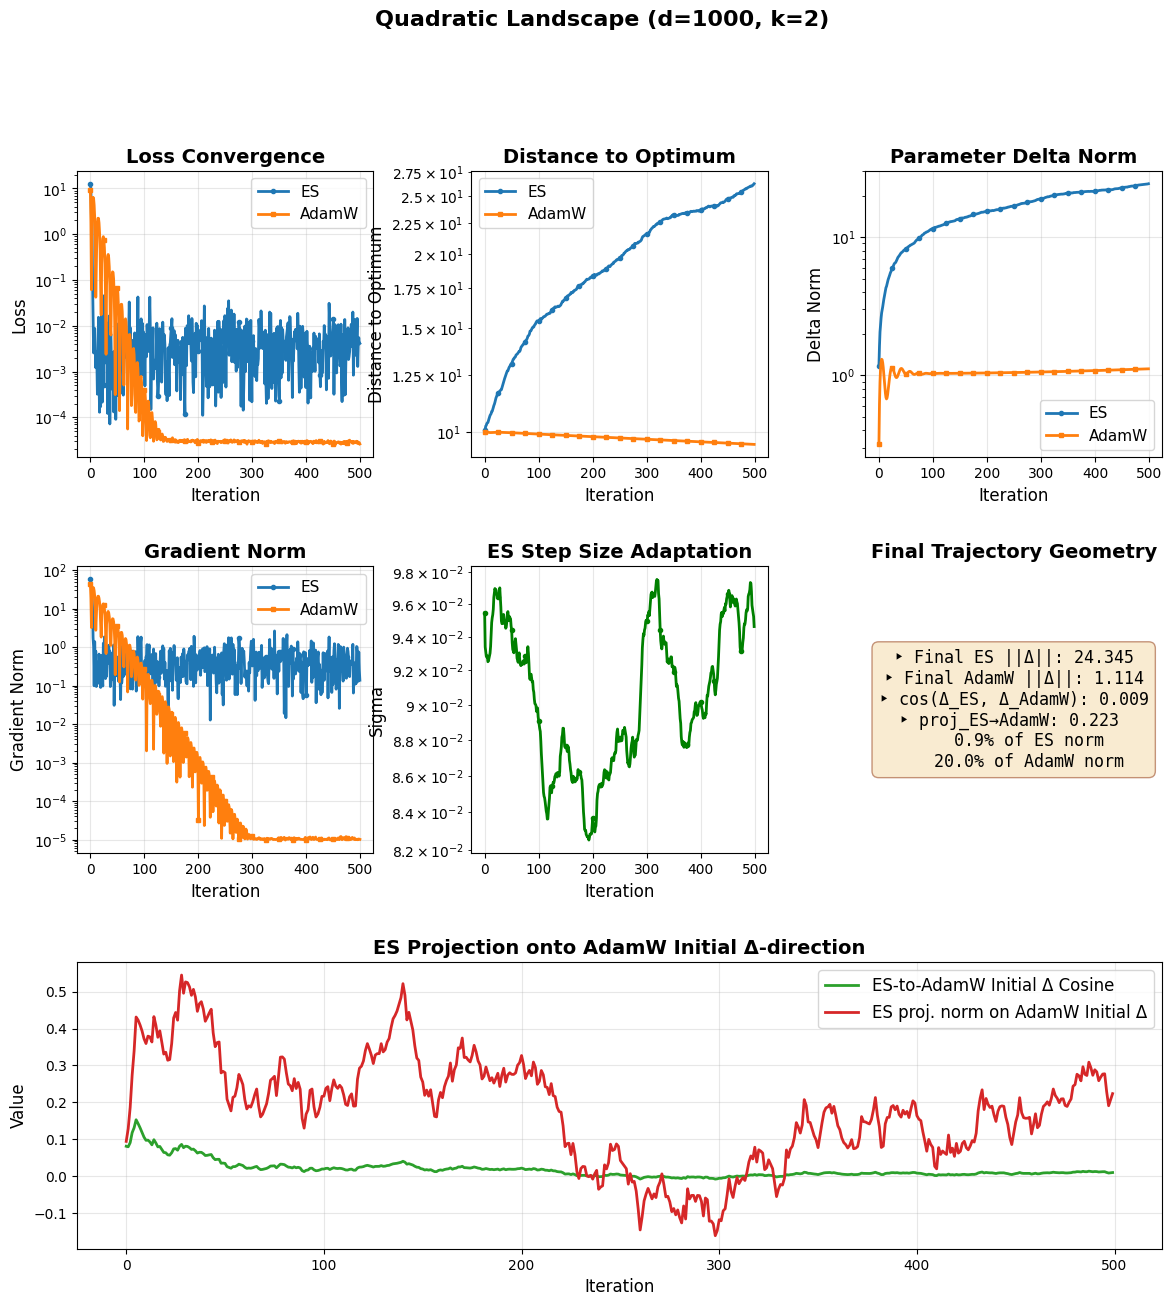

In [15]:

# ============================================================================
# VISUALIZATION - MAIN COMPARISON PLOTS
# ============================================================================

print("\nGenerating plots...")

fig = plt.figure(figsize=(14, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.38, wspace=0.33)

# Plot 1: Loss over iterations
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(es_history['iterations'], es_history['loss'],
        label='ES', linewidth=2, marker='o', markersize=3, markevery=max(1, MAX_ITERS//20))
ax1.plot(adamw_history['iterations'], adamw_history['loss'],
        label='AdamW', linewidth=2, marker='s', markersize=3, markevery=max(1, MAX_ITERS//20))
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss Convergence', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Distance to optimum
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(es_history['iterations'], es_history['distance'],
        label='ES', linewidth=2, marker='o', markersize=3, markevery=max(1, MAX_ITERS//20))
ax2.plot(adamw_history['iterations'], adamw_history['distance'],
        label='AdamW', linewidth=2, marker='s', markersize=3, markevery=max(1, MAX_ITERS//20))
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Distance to Optimum', fontsize=12)
ax2.set_title('Distance to Optimum', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Delta norm (parameter change magnitude)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(es_history['iterations'], es_history['Delta_norm'],
        label='ES', linewidth=2, marker='o', markersize=3, markevery=max(1, MAX_ITERS//20))
ax3.plot(adamw_history['iterations'], adamw_history['Delta_norm'],
        label='AdamW', linewidth=2, marker='s', markersize=3, markevery=max(1, MAX_ITERS//20))
ax3.set_xlabel('Iteration', fontsize=12)
ax3.set_ylabel('Delta Norm', fontsize=12)
ax3.set_title('Parameter Delta Norm', fontsize=14, fontweight='bold')
ax3.set_yscale('log')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Plot 4: Gradient norm
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(es_history['iterations'], es_history['grad_norm'],
        label='ES', linewidth=2, marker='o', markersize=3, markevery=max(1, MAX_ITERS//20))
ax4.plot(adamw_history['iterations'], adamw_history['grad_norm'],
        label='AdamW', linewidth=2, marker='s', markersize=3, markevery=max(1, MAX_ITERS//20))
ax4.set_xlabel('Iteration', fontsize=12)
ax4.set_ylabel('Gradient Norm', fontsize=12)
ax4.set_title('Gradient Norm', fontsize=14, fontweight='bold')
ax4.set_yscale('log')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

# Plot 5: ES Sigma adaptation
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(es_history['iterations'], es_history['sigma'],
        linewidth=2, color='green', marker='o', markersize=3, markevery=max(1, MAX_ITERS//20))
ax5.set_xlabel('Iteration', fontsize=12)
ax5.set_ylabel('Sigma', fontsize=12)
ax5.set_title('ES Step Size Adaptation', fontsize=14, fontweight='bold')
ax5.set_yscale('log')
ax5.grid(True, alpha=0.3)

# Plot 6: Final trajectory geometry summary
ax6 = fig.add_subplot(gs[1, 2])

# Compute final delta vectors
delta_es = es_final_solution - init_point
delta_adamw = adamw_final_solution - init_point

# Compute geometry metrics
norm_es = torch.norm(delta_es).item()
norm_adamw = torch.norm(delta_adamw).item()
cos_sim = torch.nn.functional.cosine_similarity(
    delta_es.view(1, -1), delta_adamw.view(1, -1)
).item()

# Projection of ES onto AdamW direction
adamw_dir = delta_adamw / (torch.norm(delta_adamw) + 1e-12)
proj_length = torch.dot(delta_es, adamw_dir).item()
proj_frac = proj_length / (norm_es + 1e-12)
proj_frac_adamw = proj_length / (norm_adamw + 1e-12)

ann_text = (f"‣ Final ES ||Δ||: {norm_es:.3f}\n"
            f"‣ Final AdamW ||Δ||: {norm_adamw:.3f}\n"
            f"‣ cos(Δ_ES, Δ_AdamW): {cos_sim:.3f}\n"
            f"‣ proj_ES→AdamW: {proj_length:.3f} \n"
            f"   {proj_frac*100:.1f}% of ES norm\n"
            f"   {proj_frac_adamw*100:.1f}% of AdamW norm")

ax6.text(0.5, 0.5, ann_text,
            ha='center', va='center', fontsize=12, transform=ax6.transAxes,
            family='monospace', bbox=dict(boxstyle='round,pad=0.4', fc='wheat', ec='sienna', alpha=0.6))
ax6.set_title('Final Trajectory Geometry', fontsize=14, fontweight='bold')
ax6.axis('off')

# Plot 7: ES projection statistics onto AdamW initial delta
ax7 = fig.add_subplot(gs[2, :])
ax7.plot(es_history['iterations'], es_proj_cosines,
            label='ES-to-AdamW Initial Δ Cosine', color='C2', linewidth=2)
ax7.plot(es_history['iterations'], es_proj_norms,
            label='ES proj. norm on AdamW Initial Δ', color='C3', linewidth=2)
ax7.set_xlabel("Iteration", fontsize=12)
ax7.set_ylabel("Value", fontsize=12)
ax7.set_title("ES Projection onto AdamW Initial Δ-direction", fontsize=14, fontweight='bold')
ax7.legend(fontsize=12)
ax7.grid(True, alpha=0.3)

plt.suptitle(f'{LANDSCAPE_TYPE.capitalize()} Landscape (d={DIM}, k={SENSITIVE_DIMS})',
            fontsize=16, fontweight='bold', y=0.995)

if SAVE_PLOT:
    plt.savefig(SAVE_PLOT, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {SAVE_PLOT}")

plt.show()



In [24]:

# ============================================================================
# TRAJECTORY PROJECTION PLOTTING UTILITIES
# ============================================================================

def plot_trajectory_projection(
    vec1,
    vec2,
    traj1,
    traj2,
    init_point,
    optimum,
    xlabel,
    ylabel,
    title=None,
    ax=None,
    show=True,
    legend=True,
):
    """
    Plots optimizer trajectories projected onto two axes defined by vec1 and vec2.

    Parameters
    ----------
    vec1, vec2 : torch.Tensor
        Axes to project onto (typically rows from landscape.rotation)
    traj1 : torch.Tensor
        Shape (num_iters, dim). First optimizer trajectory (e.g., AdamW)
    traj2 : torch.Tensor
        Shape (num_iters, dim). Second optimizer trajectory (e.g., ES)
    init_point : torch.Tensor
        Shape (dim,). Initial point
    optimum : torch.Tensor
        Shape (dim,). Landscape optimum
    xlabel, ylabel : str
        Axis labels
    title : str or None
        Optional plot title
    ax : matplotlib Axes or None
        Optional axis to plot on. If None, creates a new figure/axis.
    show : bool
        Whether to call plt.show()
    legend : bool
        Whether to display the legend
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(init_point @ vec1, init_point @ vec2, s=50, label='Initial', marker='o', color='black')
    ax.plot(traj1 @ vec1, traj1 @ vec2, label='AdamW', alpha=0.4)
    ax.plot(traj2 @ vec1, traj2 @ vec2, label='ES', alpha=0.4)
    ax.scatter(optimum @ vec1, optimum @ vec2, s=50, label='Optimum', marker='x', color='red')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    if legend:
        ax.legend()
    if show:
        plt.show()


def plot_trajectory_projections(
    landscape,
    adamw_traj,
    es_traj,
    init_point,
    optimum,
    axes_pairs=None,
    figtitle=None,
    figsize=(12, 12)
):
    """
    Plots 2D projections of optimizer trajectories onto chosen axes.

    Parameters
    ----------
    landscape : object
        The landscape object with .rotation matrix.
    adamw_traj : torch.Tensor
        AdamW optimizer trajectory (stacked tensor)
    es_traj : torch.Tensor
        Evolution Strategy trajectory (stacked tensor)
    init_point : torch.Tensor
        The initial parameter vector
    optimum : torch.Tensor
        The landscape optimum
    axes_pairs : list of tuples, optional
        List of (i, j) axis tuples (indices) to plot. Default picks four typical axes.
    figtitle : str, optional
        Figure title
    figsize : tuple, optional
        Figure size
    """
    if axes_pairs is None:
        axes_pairs = [(0, 1), (0, 2), (5, 1), (5, 2)]

    fig, axs = plt.subplots(2, 2, figsize=figsize, sharex="col", sharey="row")

    for k, (i, j) in enumerate(axes_pairs):
        row, col = divmod(k, 2)
        vec1 = landscape.rotation[i, :]
        vec2 = landscape.rotation[j, :]

        xlabel = f"{'Sensitive' if i < landscape.sensitive_dims else 'Flat'} Dimension ({i})"
        ylabel = f"{'Sensitive' if j < landscape.sensitive_dims else 'Flat'} Dimension ({j})"

        plot_trajectory_projection(
            vec1, vec2, adamw_traj, es_traj, init_point, optimum,
            xlabel=xlabel,
            ylabel=ylabel,
            title=None,
            ax=axs[row, col],
            show=False
        )

    if figtitle is None:
        figtitle = f'{LANDSCAPE_TYPE.capitalize()} Landscape (d={DIM}, k={SENSITIVE_DIMS})'

    plt.suptitle(figtitle, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()




Generating trajectory projection plots...


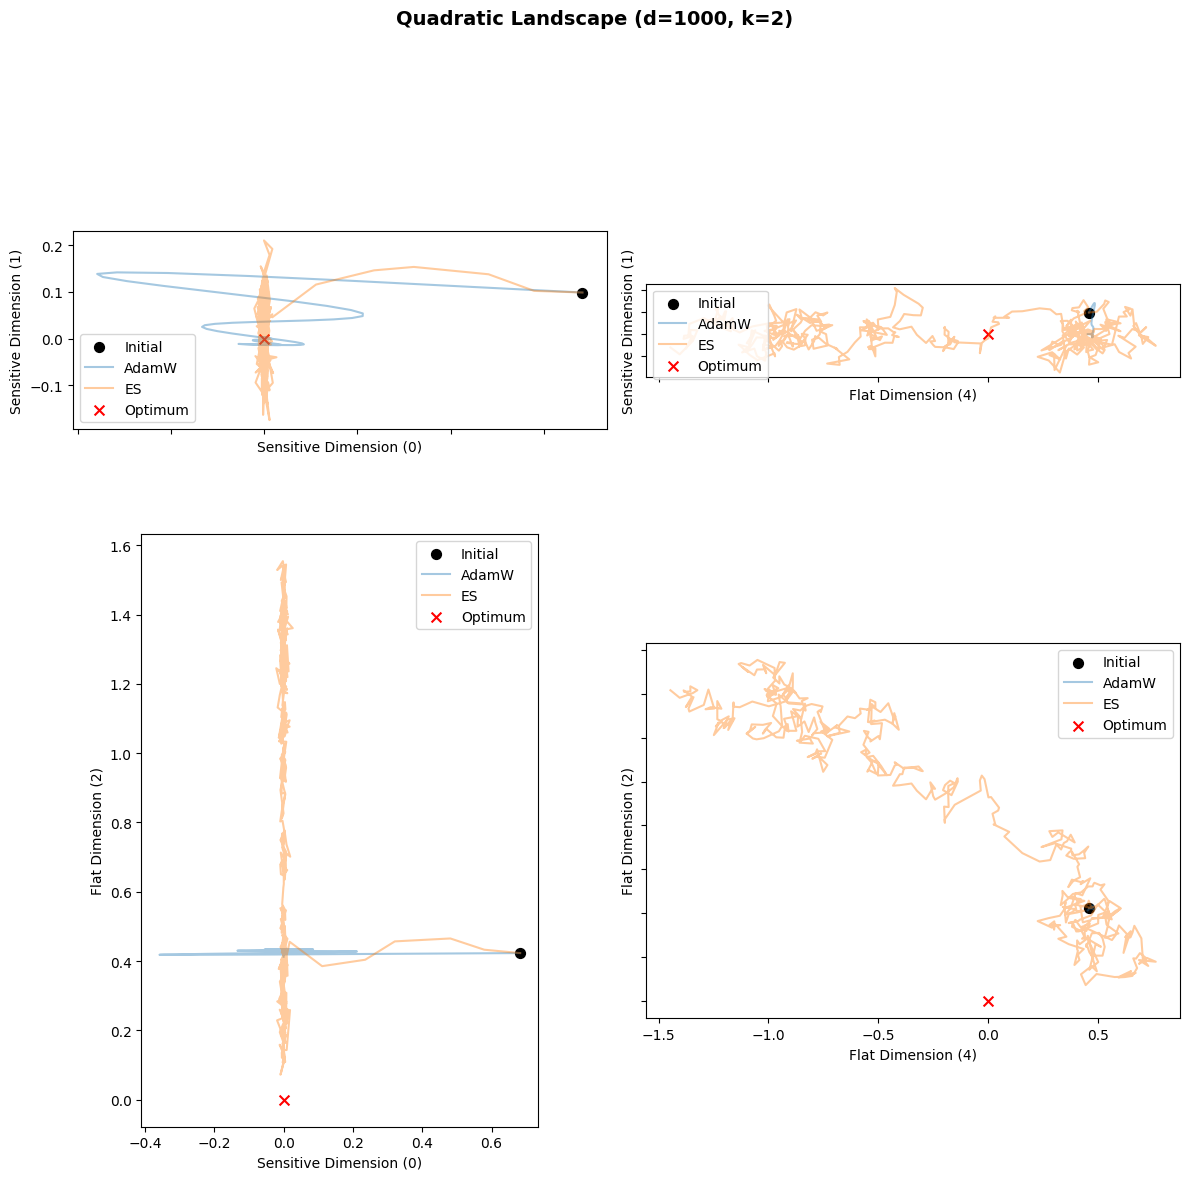


All results are available in the global scope:
  - landscape: the optimization landscape
  - optimum: the true optimum location
  - es_history: ES optimization history
  - adamw_history: AdamW optimization history
  - es_final_solution: ES final solution
  - adamw_final_solution: AdamW final solution
  - es_traj, adamw_traj: Full trajectories (stacked tensors)


In [25]:

# ============================================================================
# ADDITIONAL TRAJECTORY VISUALIZATIONS
# ============================================================================

# Stack trajectory positions into tensors
adamw_traj = torch.stack(adamw_positions)
es_traj = torch.stack(es_positions)

# Example: Plot multiple 2D projections
if SHOW_PLOTS:
    print("\nGenerating trajectory projection plots...")
    plot_trajectory_projections(
        landscape=landscape,
        adamw_traj=adamw_traj,
        es_traj=es_traj,
        init_point=init_point,
        optimum=optimum,
        axes_pairs=[(0, 1), (4, 1), (0, 2), (4, 2)]
    )


# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("All results are available in the global scope:")
print("  - landscape: the optimization landscape")
print("  - optimum: the true optimum location")
print("  - es_history: ES optimization history")
print("  - adamw_history: AdamW optimization history")
print("  - es_final_solution: ES final solution")
print("  - adamw_final_solution: AdamW final solution")
print("  - es_traj, adamw_traj: Full trajectories (stacked tensors)")
print("=" * 70)
